<a href="https://colab.research.google.com/github/Muen1/dqn-pong-formative3/blob/main/notebooks/gamma_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DQN Pong: LR & Gamma Hyperparameter Experiments
Policy: CnnPolicy vs MlpPolicy comparison, then 10 lr/gamma sweep experiments.

In [1]:
!git clone https://github.com/Muen1/dqn-pong-formative3.git
%cd dqn-pong-formative3
!pip install -r requirements.txt

Cloning into 'dqn-pong-formative3'...
remote: Enumerating objects: 58, done.
remote: Total 58 (delta 0), reused 0 (delta 0), pack-reused 58 (from 1)
Receiving objects: 100% (58/58), 74.07 MiB | 21.46 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Updating files: 100% (17/17), done.
/content/dqn-pong-formative3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 9.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 10.9 MB/s eta 0:00:00
  Created wheel for AutoROM.accept-rom-license: filename=autorom_accept_rom_license-0.6.1-py3-none-any.whl size=446711 sha256=4e269ccce93db9857e26e358ba2df9b0085c38c92e014596a7a09ed50bd76096
  Stored in directory: /root/.cache/pi

In [2]:
# Accept Atari ROM license
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


In [3]:
# Verify environment
import gymnasium, ale_py, stable_baselines3, torch
print("all good")

all good


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Verify pong environment loads
import gymnasium as gym
import ale_py
gym.register_envs(ale_py)
env = gym.make("PongNoFrameskip-v4")
print(env)

<OrderEnforcing<PassiveEnvChecker<AtariEnv<PongNoFrameskip-v4>>>>


## Part 1: MLP vs CNN Policy Comparison

In [ ]:
# Run CNN baseline
!python src/train.py --policy CnnPolicy --run_name cnn_baseline --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/cnn_baseline_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 495      |
|    time_elapsed     | 6        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_l

In [ ]:
# Run MLP baseline
!python src/train.py --policy MlpPolicy --run_name mlp_baseline --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/mlp_baseline_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 614      |
|    time_elapsed     | 5        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_l

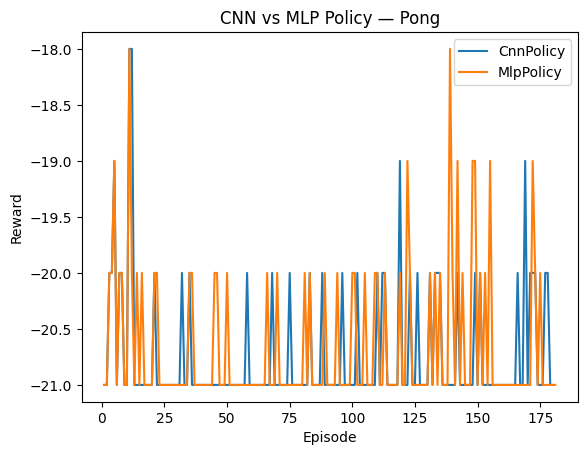

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Plot both reward curves
import pandas as pd
import matplotlib.pyplot as plt

cnn = pd.read_csv("logs/cnn_baseline_episodes.csv")
mlp = pd.read_csv("logs/mlp_baseline_episodes.csv")

plt.plot(cnn["episode"], cnn["reward"], label="CnnPolicy")
plt.plot(mlp["episode"], mlp["reward"], label="MlpPolicy")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.title("CNN vs MLP Policy — Pong")
plt.savefig("logs/cnn_vs_mlp_comparison.png")
plt.show()

**Observation:** [Fill in after viewing the plot]

## Part 2: 10 Hyperparameter Experiments — Learning Rate & Gamma Sweep


In [ ]:
# Experiment 1
!python src/train.py --policy CnnPolicy --lr 1e-3 --gamma 0.99 --run_name expA_1 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_1_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 476      |
|    time_elapsed     | 7        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_1** (lr=1e-3, gamma=0.99): [noted behavior]

In [ ]:
# Experiment 2
!python src/train.py --policy CnnPolicy --lr 5e-4 --gamma 0.99 --run_name expA_2 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_2_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 604      |
|    time_elapsed     | 5        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_2** (lr=5e-4, gamma=0.99): [noted behavior]

In [ ]:
# Save progress

from google.colab import drive
drive.mount('/content/drive')

import shutil, os

backup_dir = "/content/drive/MyDrive/dqn_pong_backup"
os.makedirs(backup_dir, exist_ok=True)

for folder in ["logs", "models", "experiments"]:
    src = f"/content/dqn-pong-formative3/{folder}"
    dst = f"{backup_dir}/{folder}"
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)

print("Backup complete:", os.listdir(backup_dir))

Mounted at /content/drive
Backup complete: ['experiments']


In [ ]:
!git pull

remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 26 (delta 8), reused 18 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (26/26), 68.36 KiB | 3.60 MiB/s, done.
From https://github.com/Muen1/dqn-pong-formative3
   2e18638..bcccac4  main       -> origin/main
Updating 2e18638..bcccac4
Fast-forward
 .gitignore                        |   19 +
 README.md                         |    0
 logs/.gitkeep                     |    0
 models/.gitkeep                   |    0
 notebooks/.gitkeep                |    0
 notebooks/gamma_experiments.ipynb | 1675 +++++++++++++++++++++++++++++++++++++
 src/train.py                      |    7 +
 submission/.gitkeep               |    0
 8 files changed, 1701 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 README.md
 create mode 100644 logs/.gitkeep
 create mode 100644 models/.gitkeep
 create mode 100644 notebooks/.gitkeep
 create mo

In [ ]:
# Experiment 3
!python src/train.py --policy CnnPolicy --lr 1e-4 --gamma 0.99 --run_name expA_3 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_3_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 590      |
|    time_elapsed     | 5        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_3** (lr=1e-4, gamma=0.99): [noted behavior]

In [ ]:
# Experiment 4
!python src/train.py --policy CnnPolicy --lr 5e-5 --gamma 0.99 --run_name expA_4 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_4_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 402      |
|    time_elapsed     | 8        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

backup_dir = "/content/drive/MyDrive/dqn_pong_backup"
os.makedirs(backup_dir, exist_ok=True)

for folder in ["logs", "models", "experiments"]:
    src = f"/content/dqn-pong-formative3/{folder}"
    dst = f"{backup_dir}/{folder}"
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)

print("Backup complete:", os.listdir(backup_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backup complete: ['experiments']


**expA_4** (lr=5e-5, gamma=0.99): [noted behavior]

In [5]:
# Confirm checkpoint update
!git log --oneline -5

cca27bf (HEAD -> main, origin/main, origin/HEAD) feat: add episode logs and model files for CNN and MLP baselines
4b14c41 chore: remove empty logs directory
bcccac4 Merge branch 'main' of https://github.com/Muen1/dqn-pong-formative3
c9822c2 feat: add checkpointing every 10k steps to resume interrupted runs
2529f1b MLP vs CNN Policy Comparison


In [6]:
# Experiment 5
!python src/train.py --policy CnnPolicy --lr 1e-5 --gamma 0.99 --run_name expA_5 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_5_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 486      |
|    time_elapsed     | 7        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_5** (lr=1e-5, gamma=0.99): [noted behavior]

In [7]:
# Experiment 6|
!python src/train.py --policy CnnPolicy --lr 1e-4 --gamma 0.999 --run_name expA_6 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_6_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 467      |
|    time_elapsed     | 7        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_6** (lr=1e-4, gamma=0.999): [noted behavior]

In [8]:
# Experiment 7
!python src/train.py --policy CnnPolicy --lr 1e-4 --gamma 0.95 --run_name expA_7 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_7_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 458      |
|    time_elapsed     | 7        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_7** (lr=1e-4, gamma=0.95): [noted behavior]

In [ ]:
# Experiment 8
!python src/train.py --policy CnnPolicy --lr 1e-4 --gamma 0.90 --run_name expA_8 --timesteps 150000

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
A.L.E: Arcade Learning Environment (version 0.9.1+aff5939)
[Powered by Stella]
Using cpu device
Wrapping the env in a VecTransposeImage.
Logging to ./tb_logs/expA_8_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 3.44e+03 |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.784    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 466      |
|    time_elapsed     | 7        |
|    total_timesteps  | 3417     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mea

**expA_8** (lr=1e-4, gamma=0.90): [noted behavior]

In [ ]:
# Experiment 9
!python src/train.py --policy CnnPolicy --lr 5e-4 --gamma 0.95 --run_name expA_9 --timesteps 150000

**expA_9** (lr=5e-4, gamma=0.95): [noted behavior]

In [ ]:
# Experiment 10
!python src/train.py --policy CnnPolicy --lr 1e-3 --gamma 0.95 --run_name expA_10 --timesteps 150000

**expA_10** (lr=1e-3, gamma=0.95): [noted behavior]

In [ ]:
# Experiments Table
import csv

rows = [
    ["expA_1", 1e-3, 0.99, "FILL IN"],
    ["expA_2", 5e-4, 0.99, "FILL IN"],
    ["expA_3", 1e-4, 0.99, "FILL IN"],
    ["expA_4", 5e-5, 0.99, "FILL IN"],
    ["expA_5", 1e-5, 0.99, "FILL IN"],
    ["expA_6", 1e-4, 0.999, "FILL IN"],
    ["expA_7", 1e-4, 0.95, "FILL IN"],
    ["expA_8", 1e-4, 0.90, "FILL IN"],
    ["expA_9", 5e-4, 0.95, "FILL IN"],
    ["expA_10", 1e-3, 0.95, "FILL IN"],
]

with open("experiments/lr_gamma_experiments.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["run_name", "lr", "gamma", "noted_behavior"])
    writer.writerows(rows)

print("Table saved.")

## Part 3: Final Model — Best Combined Config

In [ ]:
# Final training run
!python src/train.py --policy CnnPolicy \
  --lr <best_lr> --gamma <best_gamma> \
  --batch_size <B_best> \
  --eps_start <B_best> --eps_end <B_best> --eps_decay_frac <B_best> \
  --run_name final --timesteps 1000000 --save_path models/dqn_model.zip